In [2]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']


plt.rcParams['axes.prop_cycle'] = plt.cycler(color=CB_color_cycle)


plt.rcParams['font.size'] = 18
plt.rcParams['legend.fontsize'] = 14

/tmp/ipykernel_21701/4096917531.py:8: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim((0,1e3))


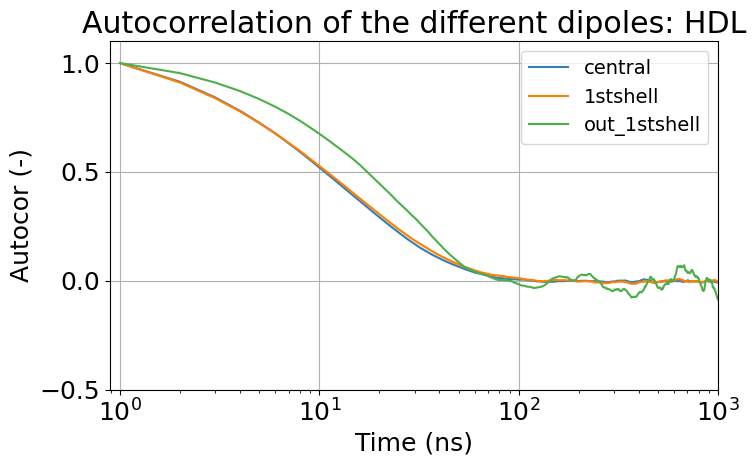

In [3]:
fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorrelation of the different dipoles: HDL")
ax.set_ylim((-0.5,1.1))
ax.set_xlim((0,1e3))


Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)


Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:10**3,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "out_1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "out_2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("autocorr_HDL.pdf")
plt.show()


In [4]:
def exp_model(x,a):
    return np.exp(-(x-0.001)/a)

In [5]:
Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000000 # micros
popt, pcov = curve_fit(exp_model, Data[:,0], Data[:,1])
a_ref = popt[0]
sig_ref = np.sqrt(pcov[0][0])
genData_ref = exp_model(Data[:,0],a_ref)

/tmp/ipykernel_21701/462625015.py:2: RuntimeWarning: overflow encountered in exp
  return np.exp(-(x-0.001)/a)


In [6]:
Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000000 # micros
popt, pcov = curve_fit(exp_model, Data[:,0], Data[:,1])
a_1st = popt[0]
sig_1st = np.sqrt(pcov[0][0])
genData_1st = exp_model(Data[:,0],a_1st)

/tmp/ipykernel_21701/462625015.py:2: RuntimeWarning: overflow encountered in exp
  return np.exp(-(x-0.001)/a)


In [7]:
Name = "2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000000 # micros
popt, pcov = curve_fit(exp_model, Data[:,0], Data[:,1])
a_2nd = popt[0]
sig_2nd = np.sqrt(pcov[0][0])

genData_2nd = exp_model(Data[:,0],a_2nd)

/tmp/ipykernel_21701/462625015.py:2: RuntimeWarning: overflow encountered in exp
  return np.exp(-(x-0.001)/a)


In [8]:
Name = "out_1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000000 # micros
popt, pcov = curve_fit(exp_model, Data[:,0], Data[:,1])
a_out_1st = popt[0]
sig_out_1st = np.sqrt(pcov[0][0])

genData_out_1st = exp_model(Data[:,0],a_out_1st)

/tmp/ipykernel_21701/462625015.py:2: RuntimeWarning: overflow encountered in exp
  return np.exp(-(x-0.001)/a)


In [9]:
Name = "out_2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000000 # micros
popt, pcov = curve_fit(exp_model, Data[:,0], Data[:,1])
a_out_2nd = popt[0]
sig_out_2nd = np.sqrt(pcov[0][0])

genData_out_2nd = exp_model(Data[:,0],a_out_2nd)

/tmp/ipykernel_21701/462625015.py:2: RuntimeWarning: overflow encountered in exp
  return np.exp(-(x-0.001)/a)


/tmp/ipykernel_21701/1472852164.py:7: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim((0,1e3))


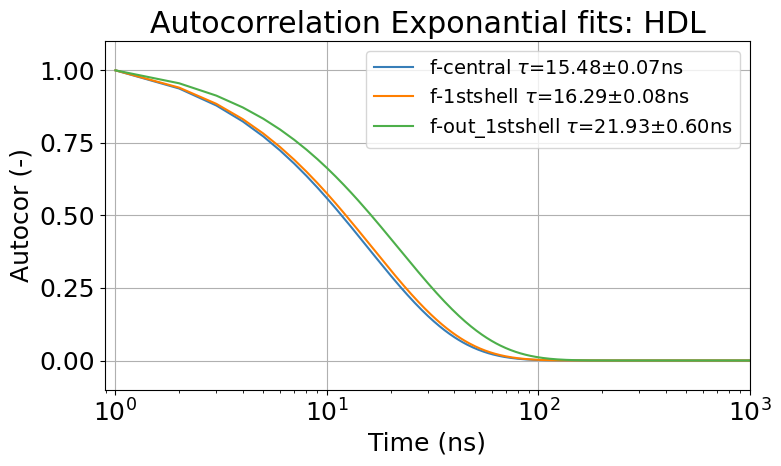

In [10]:
fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorrelation Exponantial fits: HDL")
ax.set_xlim((0,1e3))
ax.set_ylim((-0.1,1.1))


Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], genData_ref, label = f"f-{Name} $\\tau$={a_ref*1000:.2f}$\\pm${sig_ref*1000:.2f}ns")


Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], genData_1st, label = f"f-{Name} $\\tau$={a_1st*1000:.2f}$\\pm${sig_1st*1000:.2f}ns")

# Name = "2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_2nd, label = f"f-{Name} $\\tau$={a_2nd*1000:.2f}$\\pm${sig_2nd*1000:.2f}ns")

Name = "out_1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], genData_out_1st, label = f"f-{Name} $\\tau$={a_out_1st*1000:.2f}$\\pm${sig_out_1st*1000:.2f}ns")

# Name = "out_2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_out_2nd, label = f"f-{Name} $\\tau$={a_out_2nd*1000:.2f}$\\pm${sig_out_2nd*1000:.2f}ns")

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("fit_autocorr_HDL.pdf")
plt.show()


/tmp/ipykernel_21701/1584066491.py:7: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim((0,1e3))


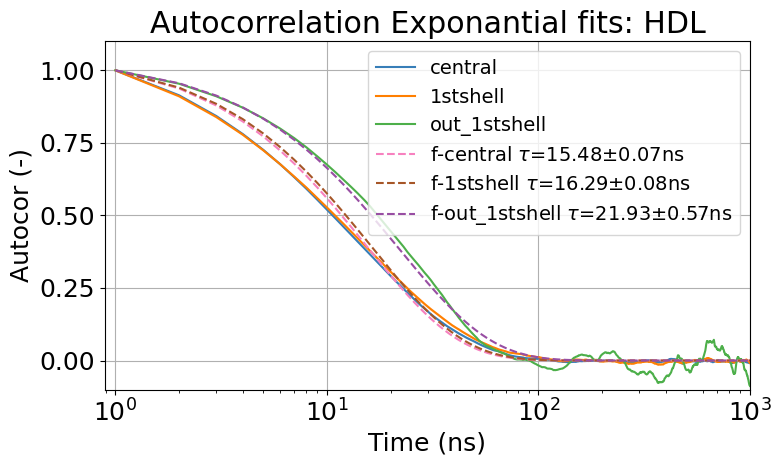

In [11]:
fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorrelation Exponantial fits: HDL")
ax.set_xlim((0,1e3))
ax.set_ylim((-0.1,1.1))

Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "out_1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "out_2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)


Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], genData_ref, label = f"f-{Name} $\\tau$={a_ref*1000:.2f}$\\pm${sig_ref*1000:.2f}ns", linestyle = '--')


Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], genData_1st, label = f"f-{Name} $\\tau$={a_1st*1000:.2f}$\\pm${sig_1st*1000:.2f}ns", linestyle = '--')

# Name = "2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_2nd, label = f"f-{Name} $\\tau$={a_2nd*1000:.2f}$\\pm${sig_2nd*1000:.2f}ns", linestyle = '--')

Name = "out_1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], genData_out_1st, label = f"f-{Name} $\\tau$={a_out_1st*1000:.2f}$\\pm${sig_out_2nd*1000:.2f}ns", linestyle = '--')

# Name = "out_2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_out_2nd, label = f"f-{Name} $\\tau$={a_out_2nd*1000:.2f}$\\pm${sig_out_2nd*1000:.2f}ns", linestyle = '--')

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("fitnraw_autocorr_HDL.pdf")

plt.show()


/tmp/ipykernel_21701/469153175.py:8: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim((0,10))


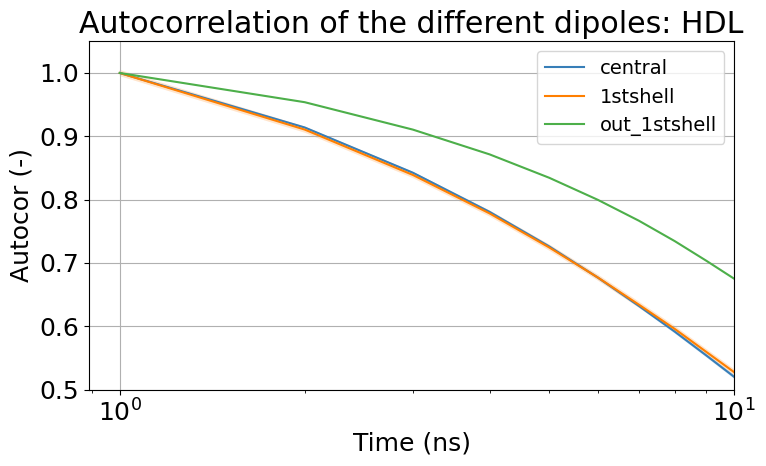

In [12]:
fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorrelation of the different dipoles: HDL")
ax.set_ylim((0.5,1.05))
ax.set_xlim((0,10))


Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)


Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "out_1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "out_2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
#plt.savefig("autocorr_HDL.pdf")
plt.show()

/tmp/ipykernel_21701/2563287046.py:7: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim((0,1e3))


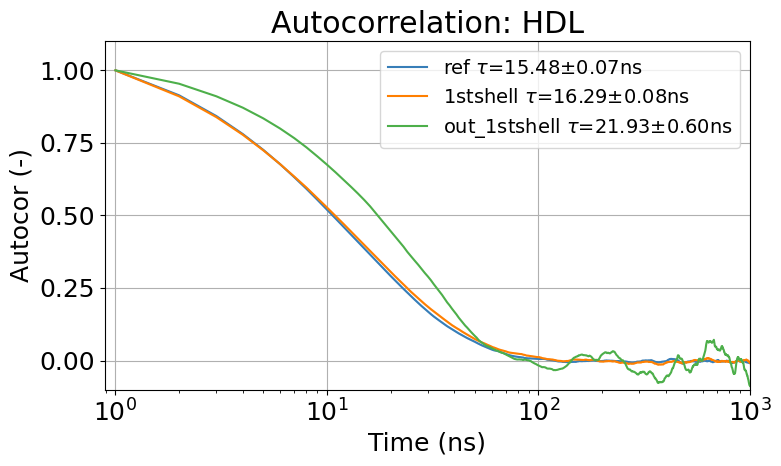

In [13]:
fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorrelation: HDL")
ax.set_xlim((0,1e3))
ax.set_ylim((-0.1,1.1))

Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = f"ref $\\tau$={a_ref*1000:.2f}$\\pm${sig_ref*1000:.2f}ns")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = f"{Name} $\\tau$={a_1st*1000:.2f}$\\pm${sig_1st*1000:.2f}ns")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "out_1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = f"{Name} $\\tau$={a_out_1st*1000:.2f}$\\pm${sig_out_1st*1000:.2f}ns")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "out_2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)


# Name = "central"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_ref, label = f"f-{Name} $\\tau$={a_ref*1000:.2f}$\\pm${sig_ref*1000:.2f}ns", linestyle = '--')


# Name = "1stshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_1st, label = f"f-{Name} $\\tau$={a_1st*1000:.2f}$\\pm${sig_1st*1000:.2f}ns", linestyle = '--')

# # Name = "2ndshell"
# # Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# # Data[:,1]/=Data[0,1]
# # Data[:,2]/=Data[0,1]
# # Data[:,0]/=1000000
# # prevplot = ax.plot(Data[:,0], genData_2nd, label = f"f-{Name} $\\tau$={a_2nd*1000:.2f}$\\pm${sig_2nd*1000:.2f}ns", linestyle = '--')

# Name = "out_1stshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_out_1st, label = f"f-{Name} $\\tau$={a_out_1st*1000:.2f}$\\pm${sig_out_2nd*1000:.2f}ns", linestyle = '--')

# # Name = "out_2ndshell"
# # Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# # Data[:,1]/=Data[0,1]
# # Data[:,2]/=Data[0,1]
# # Data[:,0]/=1000000
# # prevplot = ax.plot(Data[:,0], genData_out_2nd, label = f"f-{Name} $\\tau$={a_out_2nd*1000:.2f}$\\pm${sig_out_2nd*1000:.2f}ns", linestyle = '--')

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("rawntime_autocorr_HDL.pdf", dpi=300)

plt.show()

/tmp/ipykernel_21701/1235812177.py:7: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim((0,1e3))


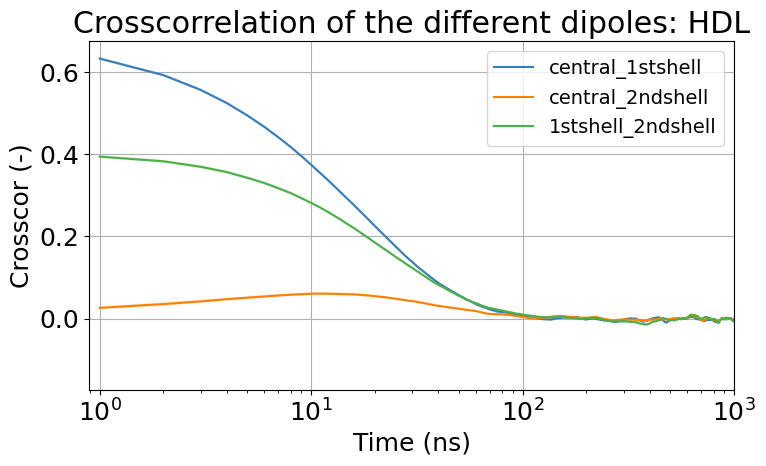

In [14]:
fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Crosscor (-)")
ax.set_title("Crosscorrelation of the different dipoles: HDL")
ax.set_xlim((0,1e3))

Name = "central_1stshell"
Subnames=Name.split('_')
Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[1:,:]
Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[1:,:]
Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[1:,:]
Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "central_2ndshell"
Subnames=Name.split('_')
Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[1:,:]
Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[1:,:]
Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[1:,:]
Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "1stshell_2ndshell"
Subnames=Name.split('_')
Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[1:,:]
Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[1:,:]
Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[1:,:]
Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)


ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("crosscorr_HDL.pdf")
plt.show()


/tmp/ipykernel_21701/3760971938.py:7: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim((0,1e3))


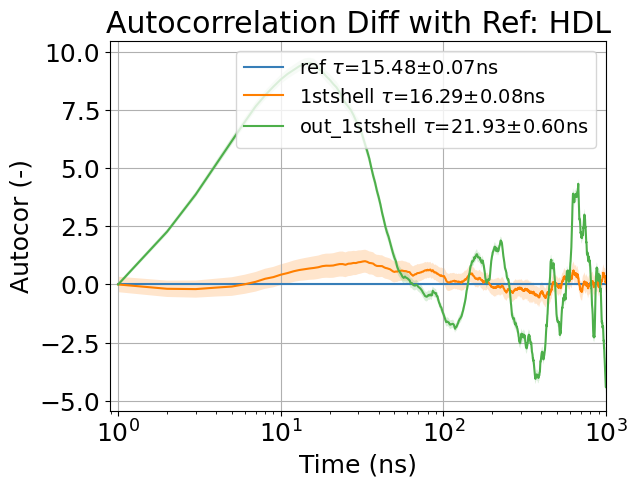

In [15]:
fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorrelation Diff with Ref: HDL")
ax.set_xlim((0,1e3))
# ax.set_ylim((-1,1))


Name = "central"
Ref = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:10**3,:]
Rescale = Ref[0,1]
Ref[:,1]/=Rescale
Ref[:,2]/=Rescale
Ref[:,0]/=1000000

Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:10**3,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000

Data[:,1] -= Ref[:,1]
Data[:,2] += Ref[:,2]
Data_absmax = np.max(np.abs(Data[:,1]))
# Data[:,1] /= Data_absmax
# Data[:,2] /= Data_absmax

prevplot = ax.plot(Data[:,0], Data[:,1], label = f"ref $\\tau$={a_ref*1000:.2f}$\\pm${sig_ref*1000:.2f}ns")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:10**3,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000

Data[:,1] -= Ref[:,1]
Data[:,2] += Ref[:,2]
Data_absmax = np.max(np.abs(Data[:,1]))
Data[:,1] /= Data_absmax
Data[:,2] /= Data_absmax

prevplot = ax.plot(Data[:,0], Data[:,1], label = f"{Name} $\\tau$={a_1st*1000:.2f}$\\pm${sig_1st*1000:.2f}ns")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "out_1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:10**3,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000

Data[:,1] -= Ref[:,1]
Data[:,2] += Ref[:,2]
#Data_absmax = np.max(np.abs(Data[:,1]))
Data[:,1] /= Data_absmax
Data[:,2] /= Data_absmax

prevplot = ax.plot(Data[:,0], Data[:,1], label = f"{Name} $\\tau$={a_out_1st*1000:.2f}$\\pm${sig_out_1st*1000:.2f}ns")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "out_2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:10**3,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)


# Name = "central"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_ref, label = f"f-{Name} $\\tau$={a_ref*1000:.2f}$\\pm${sig_ref*1000:.2f}ns", linestyle = '--')


# Name = "1stshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_1st, label = f"f-{Name} $\\tau$={a_1st*1000:.2f}$\\pm${sig_1st*1000:.2f}ns", linestyle = '--')

# # Name = "2ndshell"
# # Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# # Data[:,1]/=Data[0,1]
# # Data[:,2]/=Data[0,1]
# # Data[:,0]/=1000000
# # prevplot = ax.plot(Data[:,0], genData_2nd, label = f"f-{Name} $\\tau$={a_2nd*1000:.2f}$\\pm${sig_2nd*1000:.2f}ns", linestyle = '--')

# Name = "out_1stshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_out_1st, label = f"f-{Name} $\\tau$={a_out_1st*1000:.2f}$\\pm${sig_out_2nd*1000:.2f}ns", linestyle = '--')

# # Name = "out_2ndshell"
# # Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# # Data[:,1]/=Data[0,1]
# # Data[:,2]/=Data[0,1]
# # Data[:,0]/=1000000
# # prevplot = ax.plot(Data[:,0], genData_out_2nd, label = f"f-{Name} $\\tau$={a_out_2nd*1000:.2f}$\\pm${sig_out_2nd*1000:.2f}ns", linestyle = '--')

ax.legend()
ax.grid()
plt.savefig("rawntime_refdiff_autocorr_HDL.pdf", dpi=300)

plt.show()